In [41]:
%matplotlib inline

In [42]:
from pathlib import Path
import time
import asyncio
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [6]:
path_iberico = Path("$HOME/datasets/food-on-table/heo-iberico")
path_iberico

PosixPath('$HOME/datasets/food-on-table/heo-iberico')

In [7]:
path_iberico.exists()

False

In [8]:
path_iberico = Path("~/datasets/food-on-table/heo-iberico")
path_iberico.exists()

False

In [11]:
path_iberico = Path.home() / "datasets/food-on-table/heo-iberico"
path_iberico.exists()

True

In [12]:
path_iberico

PosixPath('/home/phunc20/datasets/food-on-table/heo-iberico')

In [13]:
list(path_iberico.glob("000[0-9]*000"))  # we need to use list() because glob() returns a generator.

[PosixPath('/home/phunc20/datasets/food-on-table/heo-iberico/00010000181000000'),
 PosixPath('/home/phunc20/datasets/food-on-table/heo-iberico/00000005586000000')]

In [17]:
! [ ! -z heo_table_corners.py ] && printf "not exist" || printf "exist"

not exist

In [20]:
! [ ! -z heo_table_corners.py ] && ln -s /home/phunc20/datasets/food-on-table/heo-iberico/heo_table_corners.py .

ln: failed to create symbolic link './heo_table_corners.py': File exists


In [21]:
! [ ! -z heo_table_corners.py ] && printf "not exist" || printf "exist"

not exist

In [22]:
ls

 01_finding_primes.ipynb
 02_untar_heavy.ipynb
 03_crop_iberico_tables.ipynb
 heo_table_corners.py@
'Python tricks - Demystifying async, await, and asyncio-tSLDcRkgTsY.mp4'@
 requirements.txt
 trash.py


In [28]:
from heo_table_corners import table_corners
n_tables = table_corners.shape[0]
n_tables

9

In [35]:
?Path.mkdir

In [36]:
for folder in path_iberico.glob("000[0-9]*000"):
    for i in range(n_tables):
        Path.mkdir(Path(folder.name) / f"T{i}", parents=True)
        #print(f"{folder.name}")

In [38]:
ls 000*

00000005586000000:
T0/  T1/  T2/  T3/  T4/  T5/  T6/  T7/  T8/

00010000181000000:
T0/  T1/  T2/  T3/  T4/  T5/  T6/  T7/  T8/


In [39]:
len(list(path_iberico.glob("000[0-9]*000/*.jpg")))

21582

In [44]:
example_image = cv2.imread(str(path_iberico/"00000005586000000/00001.jpg"))
mask = np.zeros(example_image.shape[:2], dtype=np.uint8)
for table in table_corners:
    cv2.fillConvexPoly(mask, table, 1)
mask = mask.astype(np.bool)
mask.shape

(1080, 1920)

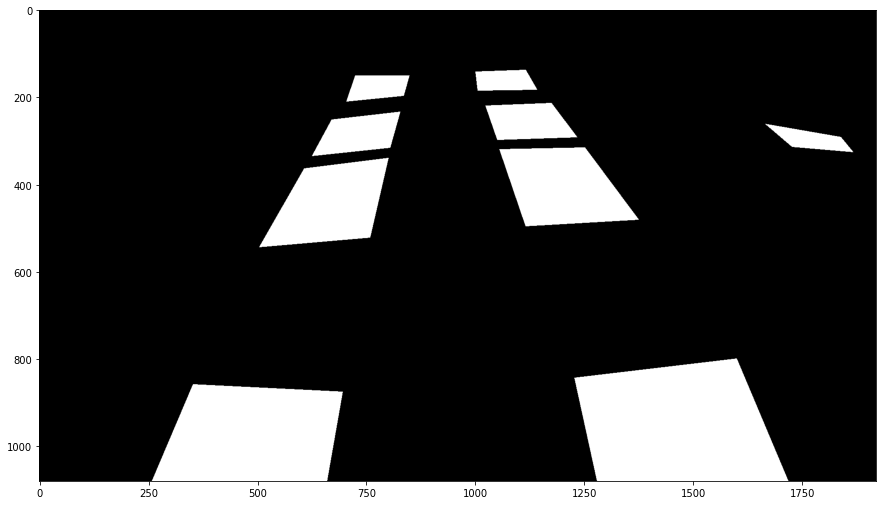

In [46]:
plt.figure(figsize=(15,15))
plt.imshow(mask, cmap="gray");

In [45]:
mask.dtype

dtype('bool')

In [53]:
def crop_one_image(image_path):
    """
    
    args:
        image_path, pathlib.Path object or str

    return:
        None
            save 8 cropped tables in T0/, T1/, ..., T7/ in the corresponding dir
            The saved path is deduced from the input arg image_path.
    """
    image = cv2.imread(str(image_path))
    blackout = np.zeros_like(image)
    blackout[mask] = image[mask]
    for i, table in enumerate(table_corners):
        # table.shape equals (4, 2)
        x_max = table[:, 0].max()
        x_min = table[:, 0].min()
        y_max = table[:, 1].max()
        y_min = table[:, 1].min()
        cropped = blackout[y_min:y_max, x_min:x_max]
        save_under = Path(image_path.parent.name) / f"T{i}" / image_path.name
        # Keep the same filename at this stage.
        # Only modify the filename when filename repetition could occur.
        cv2.imwrite(str(save_under), cropped)

In [47]:
test_path = path_iberico / "00000005586000000/00007.jpg"
test_path.exists()

True

In [49]:
test_path.parent.name

'00000005586000000'

In [50]:
test_path.name

'00007.jpg'

In [54]:
crop_one_image(test_path)

In [55]:
!tree 000*

00000005586000000
├── T0
│   └── 00007.jpg
├── T1
│   └── 00007.jpg
├── T2
│   └── 00007.jpg
├── T3
│   └── 00007.jpg
├── T4
│   └── 00007.jpg
├── T5
│   └── 00007.jpg
├── T6
│   └── 00007.jpg
├── T7
│   └── 00007.jpg
└── T8
    └── 00007.jpg
00010000181000000
├── T0
├── T1
├── T2
├── T3
├── T4
├── T5
├── T6
├── T7
└── T8

18 directories, 9 files


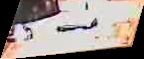

In [56]:
from IPython.display import Image
Image(filename="00000005586000000/T0/00007.jpg") 

In [57]:
!rm 00000005586000000/T*/*.jpg

In [58]:
!tree 000*

00000005586000000
├── T0
├── T1
├── T2
├── T3
├── T4
├── T5
├── T6
├── T7
└── T8
00010000181000000
├── T0
├── T1
├── T2
├── T3
├── T4
├── T5
├── T6
├── T7
└── T8

18 directories, 0 files


### Use `asyncio`

In [59]:
async def crop_one_image(image_path):
    """
    
    args:
        image_path, pathlib.Path object or str

    return:
        None
            save 8 cropped tables in T0/, T1/, ..., T7/ in the corresponding dir
            The saved path is deduced from the input arg image_path.
    """
    image = cv2.imread(str(image_path))
    blackout = np.zeros_like(image)
    blackout[mask] = image[mask]
    for i, table in enumerate(table_corners):
        # table.shape equals (4, 2)
        x_max = table[:, 0].max()
        x_min = table[:, 0].min()
        y_max = table[:, 1].max()
        y_min = table[:, 1].min()
        cropped = blackout[y_min:y_max, x_min:x_max]
        save_under = Path(image_path.parent.name) / f"T{i}" / image_path.name
        # Keep the same filename at this stage.
        # Only modify the filename when filename repetition could occur.
        await cv2.imwrite(str(save_under), cropped)

async def main():
    all_frames = path_iberico.glob("000[0-9]*000/*.jpg")
    t0 = time.time()
    await asyncio.wait([ crop_one_image(p) for p in all_frames ])
    t1 = time.time()
    print(f"Took {1000*(t1-t0)} ms")

In [61]:
all_frames = path_iberico.glob("000[0-9]*000/*.jpg")
list(all_frames)[:10]

[PosixPath('/home/phunc20/datasets/food-on-table/heo-iberico/00010000181000000/00631.jpg'),
 PosixPath('/home/phunc20/datasets/food-on-table/heo-iberico/00010000181000000/06932.jpg'),
 PosixPath('/home/phunc20/datasets/food-on-table/heo-iberico/00010000181000000/01216.jpg'),
 PosixPath('/home/phunc20/datasets/food-on-table/heo-iberico/00010000181000000/04752.jpg'),
 PosixPath('/home/phunc20/datasets/food-on-table/heo-iberico/00010000181000000/02922.jpg'),
 PosixPath('/home/phunc20/datasets/food-on-table/heo-iberico/00010000181000000/06116.jpg'),
 PosixPath('/home/phunc20/datasets/food-on-table/heo-iberico/00010000181000000/09114.jpg'),
 PosixPath('/home/phunc20/datasets/food-on-table/heo-iberico/00010000181000000/06543.jpg'),
 PosixPath('/home/phunc20/datasets/food-on-table/heo-iberico/00010000181000000/08731.jpg'),
 PosixPath('/home/phunc20/datasets/food-on-table/heo-iberico/00010000181000000/08210.jpg')]

In [62]:
main()

<coroutine object main at 0x7f085f0bd170>

In [64]:
import nest_asyncio
nest_asyncio.apply()

In [ ]:
loop = asyncio.get_event_loop()
loop.run_until_complete(main())